In [5]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from play_multi_agent import run_game
from IPython.display import clear_output

In [8]:
NUM_GAMES = 50
TRIBES = ["Xin Xi", "Imperius", "Bardur", "Oumaji"]

# Format: (Name, Path_or_JavaAgent)
AGENT_A = ("Random", "Random")
AGENT_B = ("DQN", "checkpoints/dqn.pt")

results_data = []

print(f"Starting evaluation: {NUM_GAMES} games between {AGENT_A[0]} and {AGENT_B[0]}")

for i in range(NUM_GAMES):
    # Randomize who plays first
    agents_info = [AGENT_A, AGENT_B]
    random.shuffle(agents_info)
    
    # Extract paths for run_game
    agents = [info[1] for info in agents_info]
    
    # Randomize tribes
    tribes = random.sample(TRIBES, 2)
    
    print(f"\nGame {i+1}/{NUM_GAMES}")
    print(f"Player 0: {agents_info[0][0]} ({tribes[0]})")
    print(f"Player 1: {agents_info[1][0]} ({tribes[1]})")
    
    # Run the game
    res = run_game(
        agents=agents,
        tribes=tribes,
        level_seed=-1,
        game_seed=-1,
        max_steps=2000,
        visuals=False,
        delay=0.0,
        compile_first=(i == 0)
    )
    
    # Store results
    game_record = {"game_index": i}
    for idx, player in enumerate(res['players']):
        agent_name = agents_info[idx][0]
        game_record[f"{agent_name}_tribe"] = player['tribe']
        game_record[f"{agent_name}_score"] = player['score']
        game_record[f"{agent_name}_status"] = player['status']
        
    results_data.append(game_record)
    clear_output(wait=True)
    
    name_a = AGENT_A[0]
    name_b = AGENT_B[0]
    print(f"Finished Game {i+1}/{NUM_GAMES}. Latest Result: {name_a} {game_record[f'{name_a}_status']} ({game_record[f'{name_a}_score']}) vs {name_b} {game_record[f'{name_b}_status']} ({game_record[f'{name_b}_score']})")

print("\nEvaluation complete!")
df = pd.DataFrame(results_data)
display(df.head())

Finished Game 11/50. Latest Result: Random LOSS (2186) vs DQN WIN (3131)

Game 12/50
Player 0: DQN (Oumaji)
Player 1: Random (Bardur)


UnboundLocalError: cannot access local variable 'env' where it is not associated with a value

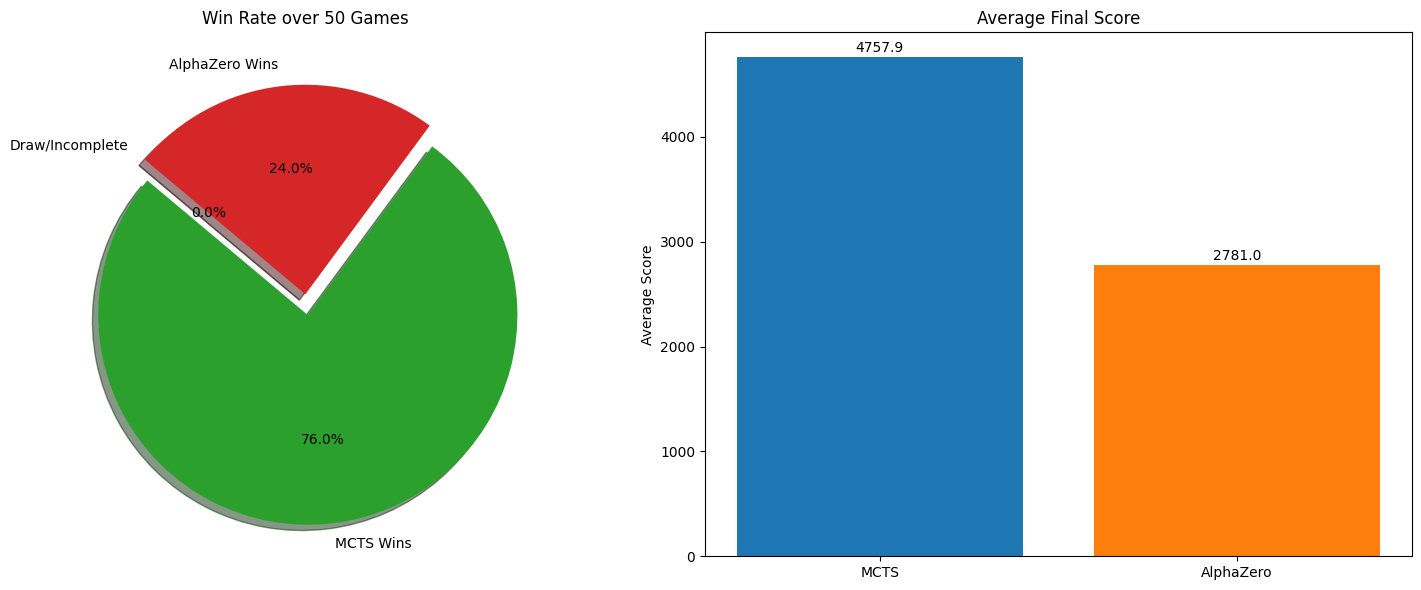

In [4]:
# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

name_a = AGENT_A[0]
name_b = AGENT_B[0]

# 1. Win Rate Pie Chart
agent_a_wins = len(df[df[f'{name_a}_status'] == 'WIN'])
agent_b_wins = len(df[df[f'{name_b}_status'] == 'WIN'])
draws = NUM_GAMES - agent_a_wins - agent_b_wins

labels = [f'{name_a} Wins', f'{name_b} Wins', 'Draw/Incomplete']
sizes = [agent_a_wins, agent_b_wins, draws]
colors = ['#2ca02c', '#d62728', '#7f7f7f']
explode = (0.1, 0, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
ax1.set_title('Win Rate over 50 Games')

# 2. Average Score Bar Chart
avg_a_score = df[f'{name_a}_score'].mean()
avg_b_score = df[f'{name_b}_score'].mean()

agents_names = [name_a, name_b]
scores = [avg_a_score, avg_b_score]

ax2.bar(agents_names, scores, color=['#1f77b4', '#ff7f0e'])
ax2.set_ylabel('Average Score')
ax2.set_title('Average Final Score')

for i, v in enumerate(scores):
    ax2.text(i, v + max(scores)*0.01, str(round(v, 1)), ha='center')

plt.tight_layout()
plt.show()